In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import date2num

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [34]:
from prophet import Prophet

In [56]:
# Load data
df = pd.read_csv('historical_stablecoin.csv')
df['date'] = pd.to_datetime(df['date'])

df.head()

,date,peggedUSD,peggedEUR,peggedVAR,peggedJPY,peggedCNY,peggedUAH,peggedARS,peggedGBP,peggedCAD,peggedCHF,peggedAUD,peggedREAL
0,2021-01-01,28286859559,3871222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,28825490421,4272046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,28995680791,5510939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,29328599685,5971796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,29771217419,7836686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Detect first non-null date for each currency column
first_dates = {}
for col in df.columns[1:]:  # Skip 'date' column
    non_null = df[col].notna()
    if non_null.any():
        idx = non_null.idxmax()
        first_dates[col] = df.loc[idx, 'date']
    else:
        first_dates[col] = pd.NaT

launch_df = pd.DataFrame([{'currency': k, 'launch_date': v} for k, v in first_dates.items()])
launch_df = launch_df.sort_values('launch_date').reset_index(drop=True)

# Display table of launch dates
print("Launch Dates of Stablecoins:")
print(launch_df)

Launch Dates of Stablecoins:
      currency launch_date
0    peggedUSD  2021-01-01
1    peggedEUR  2021-01-01
2    peggedVAR  2021-02-14
3    peggedJPY  2023-08-10
4    peggedCNY  2023-09-01
5    peggedUAH  2023-10-04
6    peggedARS  2023-10-06
7    peggedGBP  2023-11-23
8    peggedCAD  2023-12-08
9    peggedCHF  2024-01-25
10   peggedAUD  2024-03-06
11  peggedREAL  2024-07-03


# EDA

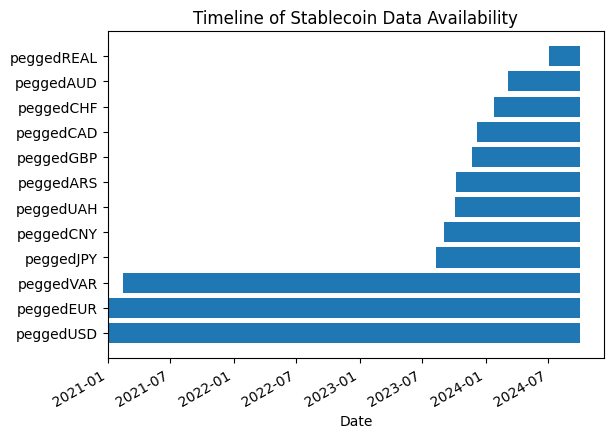

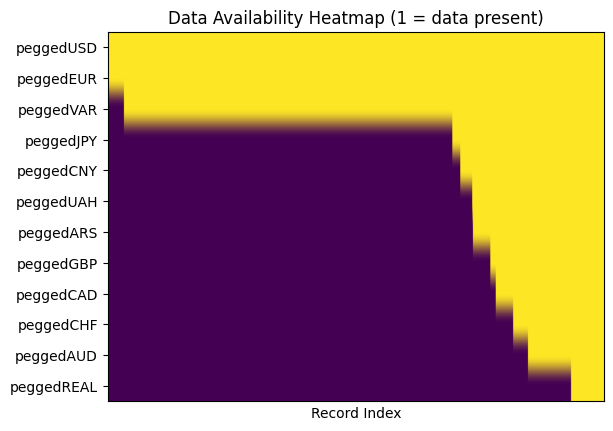

In [53]:
# Plot horizontal timeline of launches
last_date = df['date'].max()
starts = date2num(launch_df['launch_date'])
widths = date2num(last_date) - starts

plt.figure()
plt.barh(launch_df['currency'], widths, left=starts)
plt.xlabel('Date')
plt.title('Timeline of Stablecoin Data Availability')
plt.gca().xaxis_date()
plt.gcf().autofmt_xdate()
plt.show()

# Plot heatmap of data availability
availability = df.set_index('date')[launch_df['currency']].notna().T.astype(int)

plt.figure()
plt.imshow(availability, aspect='auto')
plt.yticks(range(len(availability.index)), availability.index)
plt.xticks([], [])
plt.xlabel('Record Index')
plt.title('Data Availability Heatmap (1 = data present)')
plt.show()

# VISUALISASI

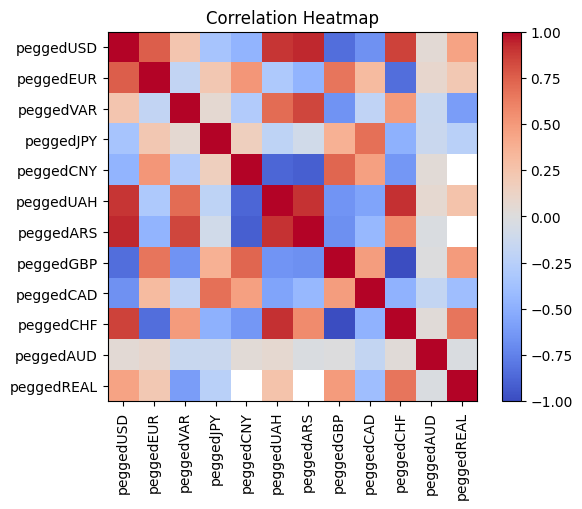

In [38]:
# Correlation Heatmap
plt.figure()
corr = df.drop(columns='date').corr()
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title('Correlation Heatmap')
plt.show()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_75756/1407442266.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')[coins].resample('M').last()


<Figure size 640x480 with 0 Axes>

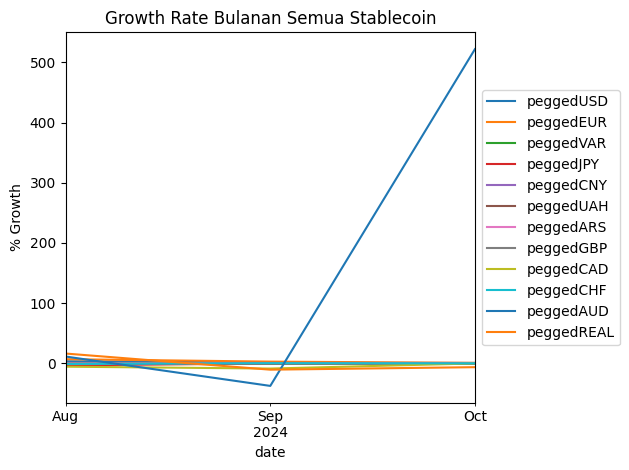

In [39]:
# Otomatis ambil semua kolom selain 'date'
coins = df.columns.drop('date')

# Lanjut sama seperti sebelumnya
monthly = df.set_index('date')[coins].resample('M').last()
growth = monthly.pct_change() * 100

plt.figure()
growth.dropna().plot()
plt.ylabel('% Growth')
plt.title('Growth Rate Bulanan Semua Stablecoin')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

/var/folders/gs/b23h8b0d4h73h3gp616lr10c0000gn/T/ipykernel_75756/1091603606.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('date')['peggedUSD'].resample('M').last()


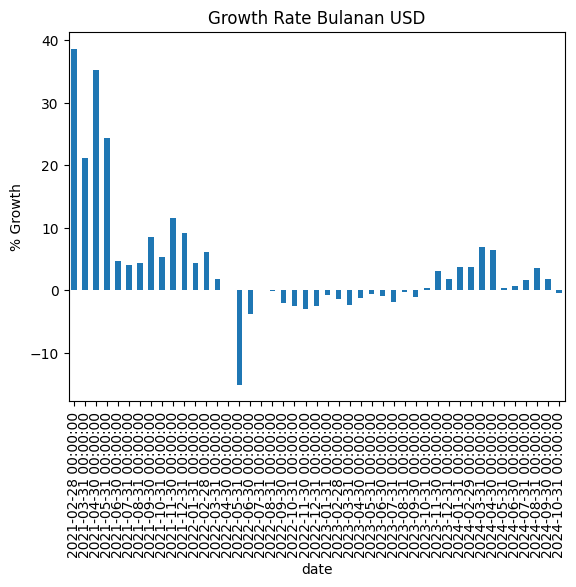

In [40]:
monthly = df.set_index('date')['peggedUSD'].resample('M').last()
growth = monthly.pct_change().dropna() * 100
growth.plot.bar()
plt.ylabel('% Growth')
plt.title('Growth Rate Bulanan USD')
plt.show()


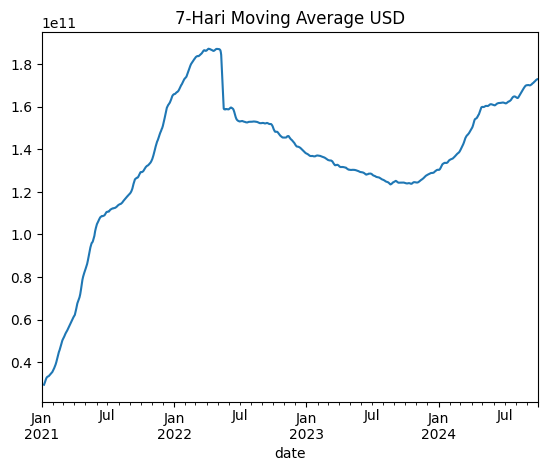

In [41]:
df.set_index('date')['peggedUSD'].rolling(7).mean().plot()
plt.title('7-Hari Moving Average USD')
plt.show()


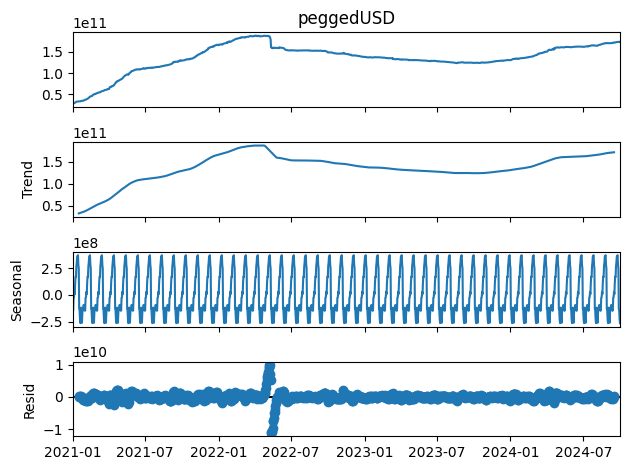

In [42]:
# 5. Seasonal Decomposition USD
series = df.set_index('date')['peggedUSD'].dropna()
res = seasonal_decompose(series, model='additive', period=30)
res.plot()
plt.show()

# Forecasting 30 Hari

21:05:20 - cmdstanpy - INFO - Chain [1] start processing
21:05:20 - cmdstanpy - INFO - Chain [1] done processing


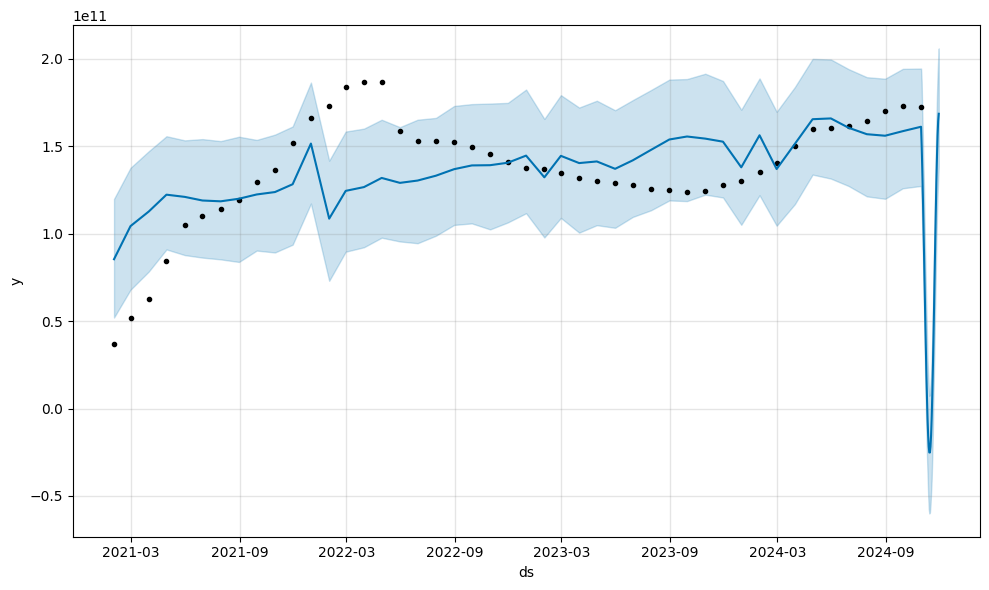

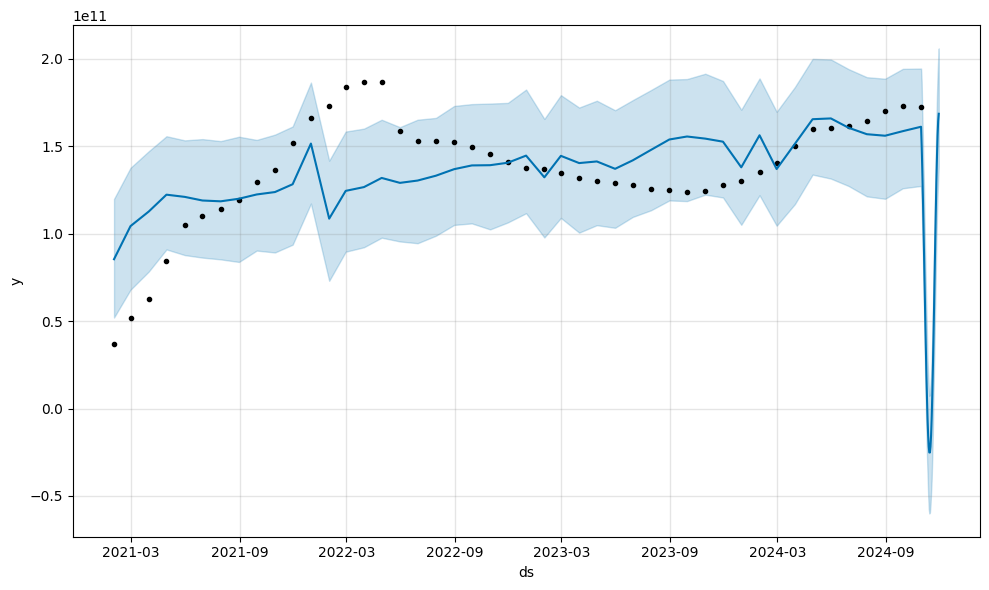

In [43]:
df_prophet = monthly.reset_index().rename(columns={'date':'ds','peggedUSD':'y'})
m = Prophet(); m.fit(df_prophet)
future = m.make_future_dataframe(periods=30, freq='D')
fc = m.predict(future)
m.plot(fc)


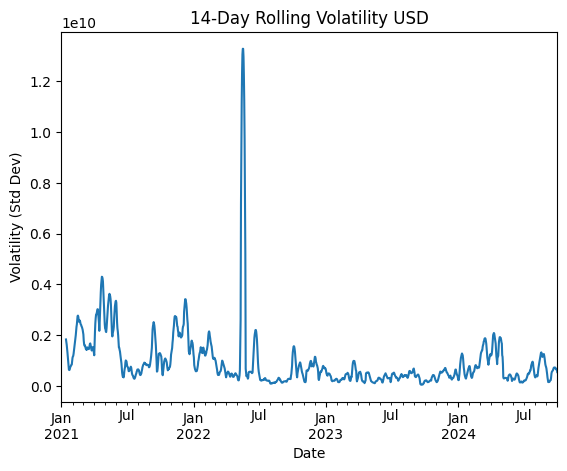

In [44]:
# 14-Day Rolling Volatility
vol = df.set_index('date')['peggedUSD'].rolling(14).std()

plt.figure()
vol.plot()
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev)')
plt.title('14-Day Rolling Volatility USD')
plt.show()

# Cek dengan anomali 